# Решатель КР 3 по Линейной Алгебре

In [51]:
from sympy import *
import sympy as sp
from IPython.display import *

def geo(m):
    """ Вывод матрицы в формате геолина """
    if m.shape[0] == 1:
        return f'[{', '.join([str(round(m[0, i], 10)) for i in range(m.shape[1])])}]'
    return f'[{'; '.join([', '.join([str(round(m[j, i], 10)) for i in range(m.shape[1])]) for j in range(m.shape[0])])}]'    

def geolin_matrix(s: str, n: int) -> Matrix:
    """ Ввод матрицы по столбцам """
    s = s.replace('\u2212', '-').replace('\u200b', '').split()
    d = MutableDenseMatrix.zeros(n, len(s) // n)
    for i in range(len(s)):
        d[i % n, i // n] = int(s[i])
    return d

def geolin_vector(s: str) -> Matrix:
    """ Ввод вектора """
    s = s.replace('\u2212', '-').replace('\u200b', '').split()
    return Matrix([int(x) for x in s])

In [52]:
""" Нахождение ортонормированного базиса и ортагональной проекции """

def dot(a, b, G): 
    return sympify((a.T * G * b)[0])

def LNZ_basis(vectors):
    matrix = Matrix.hstack(*vectors)
    rank = matrix.rank()
    if rank < len(vectors):
        display(Latex("\nВекторы линейно зависимы. Оставляем базис из", rank, "векторов."))
        column_space = matrix.columnspace()
        vectors = [vec.as_immutable() for vec in column_space]
        display(column_space)
    else:
        display(Latex("\nВсе векторы линейно независимы."))
    return vectors

def _ortho_basis(vectors, G):
    vectors = LNZ_basis(vectors)
    display(Latex("Ортагонализация Грама-Шмидта"))
    ortho_vectors = []
    for i, v in enumerate(vectors):
        u = v.copy()
        
        out = f'$\\tilde{{e}}_{i+1} = e_{i+1}'
        for j, e in enumerate(ortho_vectors):
            coeff = dot(v, e, G) / dot(e, e, G)
            u -= coeff * e
            out += f"- {coeff} * e_{j+1}"
        
        if u.norm() != 0:
            ortho_vectors.append(u)
            out += f" = {latex(u.T)}^T$."
        else:
            out += "= \\vec{0}$ -- исключаем."
        display(Latex(out))
    return ortho_vectors

def orthonormal_basis(vectors, G):
    ortho_vectors = _ortho_basis(vectors, G)
    display(Latex("Нормировка"))
    orthonormal_vectors = []
    for i, u in enumerate(ortho_vectors):
        norm = sqrt(dot(u, u, G))
        e = u / norm
        orthonormal_vectors.append(e)
        display(Latex(f"$\\tilde{{\\tilde{{e}}}}_{i+1} = \\frac{{\\tilde{{e}}}}{{{norm}}} = {latex(e.T)}^T$"))
    basis = Matrix.hstack(*orthonormal_vectors)
    display(Latex("Ортонормированный базис"), basis)
    return orthonormal_vectors

def projection(basis, y, G):
    display(Latex("Вычислим проекцию"))
    projection = Matrix.zeros(y.rows, 1)
    out = "p = "
    for i, e in enumerate(basis):
        projection += e * dot(y, e, G)
        out += f"+ {dot(y, e, G)} * e_{i + 1}"
    p = simplify(projection)
    out += f"= {latex(p.T)}^T"
    display(Math(out))
    return p

In [53]:
""" Метод Якоби """

def principal_minors(Q: Matrix) -> list:
    display(Latex("Главные миноры"))
    pms = []
    for i in range(1, Q.rows+1):
        pm = Q[:i, :i].det()
        pms.append(pm)
        display(Math(f"\\Delta_{i} = {latex(Q[:i, :i])} = {pm}"))
        if pm == 0 and i != Q.rows:
            display(Latex("Нулевой минор!"))
            return None
    return pms 

def jacobi_eigen(Q: Matrix) -> list:
    pms = principal_minors(Q)
    if pms is None:
        eigen = Q.eigenvals()
        display(Latex(f"Находим собственные числа стандартным образом: {eigen}"))
        return eigen
    eigen_values = [pms[0]]
    display(Latex("Коэффициенты в разложении Якоби (собственные числа)"))
    display(Math(f"\\alpha_1 = \\Delta_1 = {eigen_values[0]}"))
    for i in range(1, Q.rows):
        eig = pms[i] / pms[i-1]
        eigen_values.append(eig)
        display(Math(f"\\alpha_{i+1} = \\frac{{\\Delta_{i+1}}}{{\\Delta_{i}}} = {eig}"))
    return eigen_values

def signature(eigen: list):
    p, q =sum(1 for x in eigen if x > 0), sum(1 for x in eigen if x < 0)
    display(Latex(f"Cигнатура: ({p}, {q})"))
    return p, q

In [ ]:
""" Приведение к каноническому виду по Лагранжу в матричном виде """

def normalize(Q_diag, C):
    n = Q_diag.rows
    if all(Q_diag[i, i] in [0, 1, -1] for i in range(n)):
        return Q_diag, C
    Q_canonical = Matrix.eye(n)  # Каноническая матрица (±1)
    Q_scale = Matrix.eye(n)      # Матрица масштабирования
    for i in range(n):
        d = Q_diag[i, i]
        if abs(d) < 1e-10:  # Нулевой элемент
            scale = 1
            Q_canonical[i, i] = 0
        else:
            sign = 1 if d > 0 else -1
            scale = sqrt(abs(d))
            Q_canonical[i, i] = sign
        Q_scale[i, i] = scale
    # Новые координаты: z = D_scale * y (y = C * x)
    C_normalized = Q_scale * C
    display(Latex("Каноническая Q"), Q_canonical, Latex("Матрица преобразования к канонической"), C_normalized)
    return Q_canonical, C_normalized

def lagrange(Q: Matrix):
    n = Q.rows
    C = Matrix.eye(n)
    for k in range(n):
        # Нулевой элемент на главной диагонали
        if Q[k, k] == 0:
            for i in range(k + 1, n):
                if Q[i, k] != 0:
                    # Создаем матрицу перестановки строк i и k
                    P = Matrix.eye(n)
                    P[k, k], P[i, i] = 0, 0
                    P[k, i], P[i, k] = 1, 1
                    # Применяем перестановку к Q и C
                    Q = P.T * Q * P
                    C = P * C
                    display(Latex(f"Меняем местами строки {i + 1} и {k + 1}"))
                    break
            else:
                display(Math(f"x_{{{k}}} = e_{{{k}}}"))
                continue
        # Метод Лагранжа
        Ck = Matrix.eye(n)
        for i in range(k + 1, n):
            Ck[k, i] = - Q[k, i] / Q[k, k]
        Q = Ck.T * Q * Ck
        C = Ck.inv() * C
        bss = [f" {"+" if C[k, i] > 0 else "-"} {abs(C[k, i])} e_{{{i + 1}}}" for i in range(0, n) if C[k, i] != 0]
        display(Math(f"x_{{{k + 1}}}{''.join(bss)}"))
    display(Latex("Диагональная Q"), Q, Latex("Матрица преобразования к диагональной"), C)
    return Q, C

def lagrange_diagonalization(Q: Matrix):
    return normalize(*lagrange(Q))

In [55]:
""" Одновременная диагонализация двух квадратичных форм """

def double_diagonalization(Q1, Q2):
    lamda = symbols('λ')
    display(Latex("Найдём $\\lambda$ из уравнения $det(Q_1 - \\lambda Q_2) = 0$"))
    matQQ = Q1 - lamda * Q2
    display(Math(f"Q_1 - \\lambda Q_2 = {latex(matQQ)}"))
    char_poly = factor(simplify(matQQ.det()))
    display(Math(f"{char_poly} = 0"))
    
    display(Latex("Найдём собственные значения"))
    roots = sp.roots(char_poly, lamda)
    if not roots:
        roots_list = solve(char_poly, lamda)
        roots = {root: sp.root_multiplicity(char_poly, root) for root in roots_list}
    eigenvalues = sorted(roots.keys(), key=lambda x: [float(re(x)), float(im(x))])
    for i, eig_val in enumerate(eigenvalues):
        display(Math(f"\\lambda_{{{i + 1}}} = {eig_val}"))
        
    display(Latex("Нахождение собственных векторов"))
    eigenvectors = []
    for i, eig_val in enumerate(eigenvalues):
        display(Latex(f"Для $\\lambda_{{{i + 1}}} = {eig_val}$:"))
        
        N = Q1 - eig_val * Q2
        display(Math(f"N_{{{i + 1}}} = Q_1 - \\lambda_{{{i + 1}}} * Q_2 = {latex(N)}"))
        
        display(Latex(f"Собственные векторы $N_{{{i + 1}}} \\cdot X = 0$"))
        nullspace = N.nullspace()
        if nullspace:
            for vec in nullspace:
                eigenvectors.append(vec)
            display(Math("X = " + " + ".join([latex(x) + f"C_{{{k + 1}}}" for k, x in enumerate(nullspace)])))
    
    C = Matrix.hstack(*eigenvectors)
    display(Latex(f"Матрица перехода $C = {latex(C)}$"))
    
    Q1d = C.T * Q1 * C
    Q2d = C.T * Q2 * C
    display(Latex(f"Матрица канонической формы $Q_1$: $D_1 = C.T * Q_1 * C$ "))
    display(Q1d)
    display(Latex(f"Матрица диагональной формы $Q_2$: $D_2 = C.T * Q_2 * C$ "))
    display(Q2d)

    display(Latex("Обратная к матрице C - матрица преобразования"))
    display(C.inv())
    return Q1d, Q2d, C.inv()

# Задания

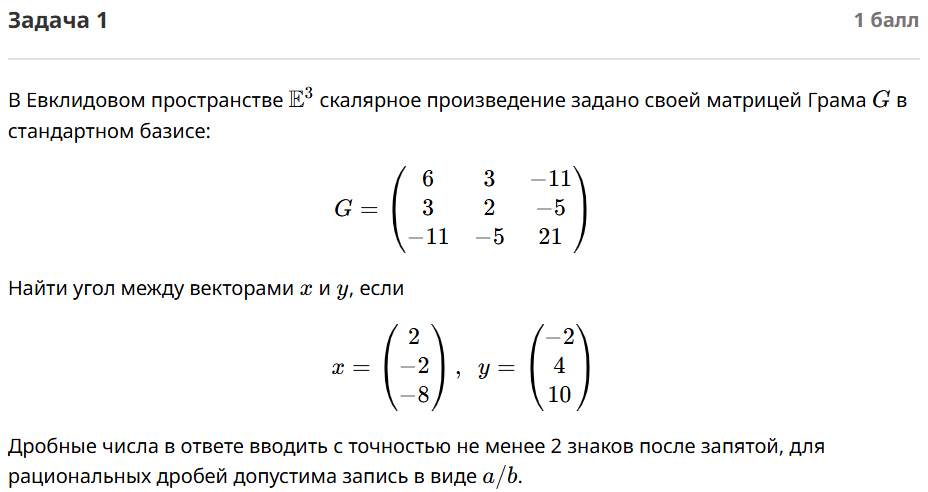

In [56]:
G = geolin_matrix("6 3 -11 3 2 -5 -11 -5 21", 3)
x = geolin_vector("2 -2 -8")
y = geolin_vector("-2 4 10")

product = (x.T @ G @ y)[0, 0] 
display(f'Скалярное произведение = {product}')

x_norm = sqrt((x.T @ G @ x)[0])
y_norm = sqrt((y.T @ G @ y)[0])
display(f"Длины векторов: {x_norm} и {y_norm}")

cos_alpha = product / (x_norm * y_norm)
display(f'Косинус угла: {cos_alpha}')

print('Ответ:')
print(acos(cos_alpha).evalf())

'Скалярное произведение = -1820'

'Длины векторов: 2*sqrt(386) и 2*sqrt(537)'

'Косинус угла: -455*sqrt(207282)/207282'

Ответ:
3.10637377275147


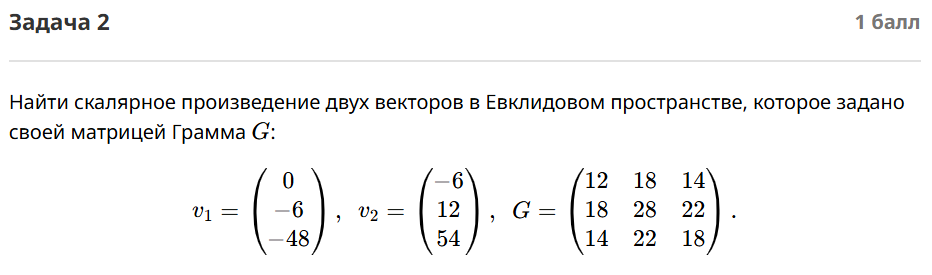

In [57]:
v1 = geolin_vector("0 -6 -48")
v2 = geolin_vector("-6 12 54")
G = geolin_matrix("12 18 14 ​ 18 28 22 ​ 14 22 18", 3)

product = v1.T * G * v2

print('Ответ:')
print(product[0, 0])

Ответ:
-63792


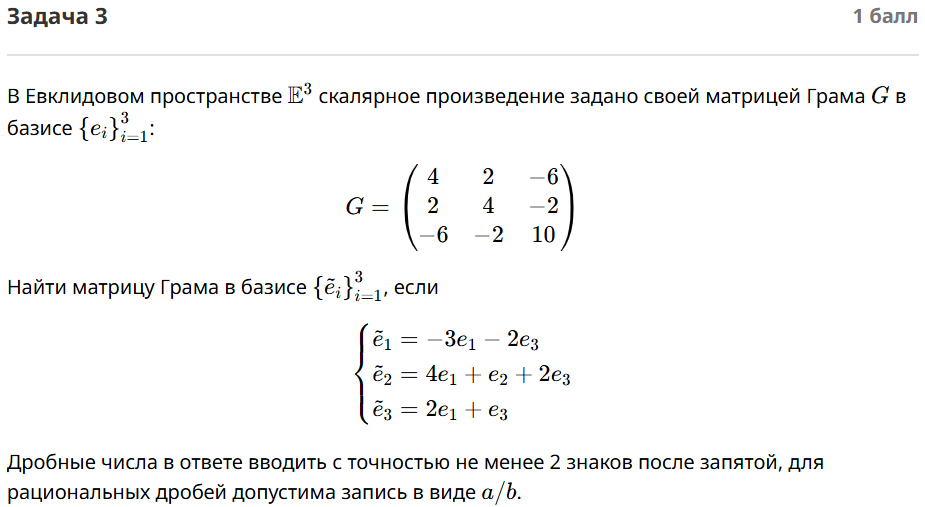

In [58]:
G = geolin_matrix("4 2 -6 2 4 -2 -6 -2 10", 3)
C = geolin_matrix("-3 0 -2 4 1 2 2 0 1", 3)

display("Матрица перехода", C)

new_G = C.T @ G @ C
display("Матрица грамма в новом базисе", new_G)

print('Ответ:')
print(geo(new_G))

'Матрица перехода'

Matrix([
[-3, 4, 2],
[ 0, 1, 0],
[-2, 2, 1]])

'Матрица грамма в новом базисе'

Matrix([
[ 4, -6, -2],
[-6, 20,  6],
[-2,  6,  2]])

Ответ:
[4, -6, -2; -6, 20, 6; -2, 6, 2]


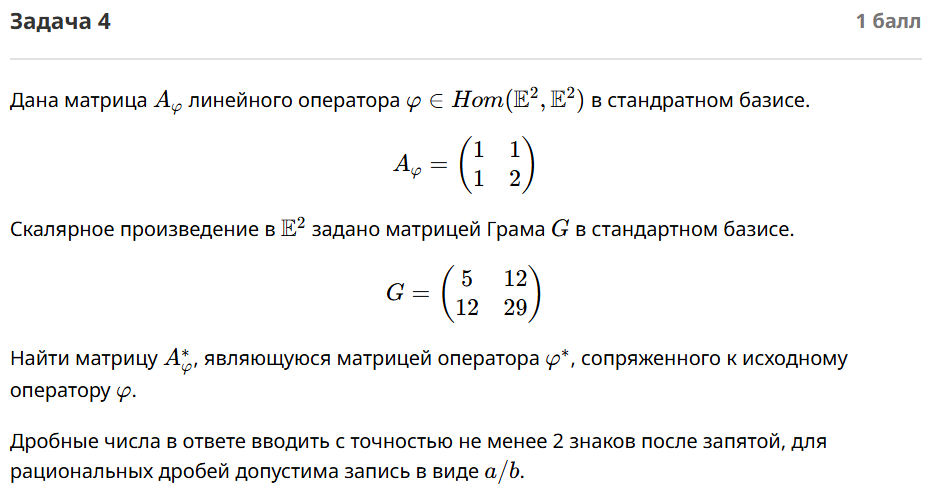

In [59]:
A = geolin_matrix("1 1 1 2", 2)
G = geolin_matrix("5 12 12 29", 2)

Ad = G.inv() * A.T * G
display(Latex("$G^{-1}$"), G.inv())
display(Latex("$A^\\dagger = G^{-1} \\times A^T \\times G$"), Ad)
display(Latex("Ответ"))
print(geo(Ad))

<IPython.core.display.Latex object>

Matrix([
[ 29, -12],
[-12,   5]])

<IPython.core.display.Latex object>

Matrix([
[145,  349],
[-59, -142]])

<IPython.core.display.Latex object>

[145, 349; -59, -142]


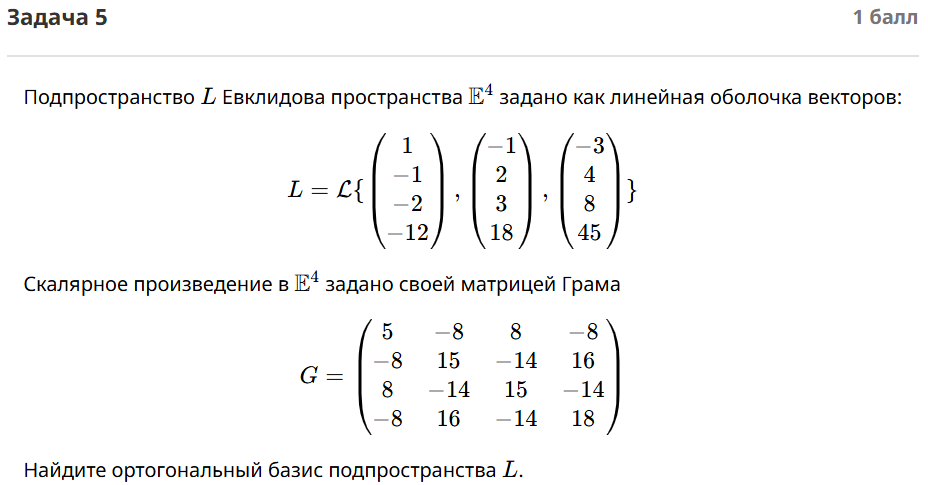

In [60]:
G = geolin_matrix("5 -8 8 -8 -8 15 -14 16 8 -14 15 -14 -8 16 -14 18", 4)
vectors = [
    geolin_vector("1 -1 -2 -12"),
    geolin_vector("-1 2 3 18"),
    geolin_vector("-3 4 8 45")
]

basis = _ortho_basis(vectors, G)
print(geo(Matrix.hstack(*basis).T))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

[1, -1, -2, -12; 0.5187699681, 0.4812300319, -0.0375399361, -0.2252396166; -0.0983050847, -0.4576271186, 0.6406779661, 0.8440677966]


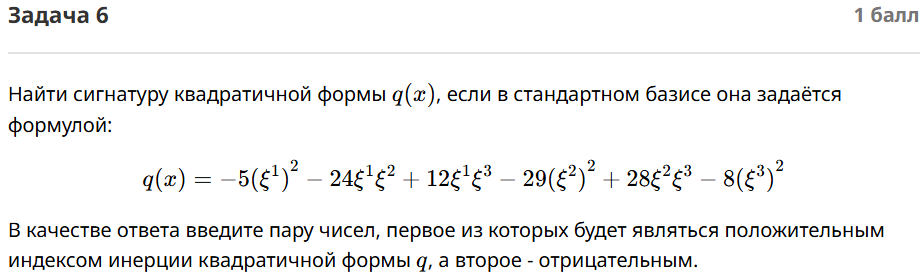

In [61]:
Q = Matrix([
    [-5, -12, 6],
    [-12, -29, 14],
    [6, 14, -8]
])
p, q = signature(jacobi_eigen(Q))
display(Latex("Ответ"))
print(f"[{p}, {q}]")

<IPython.core.display.Latex object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Latex object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

[0, 2]


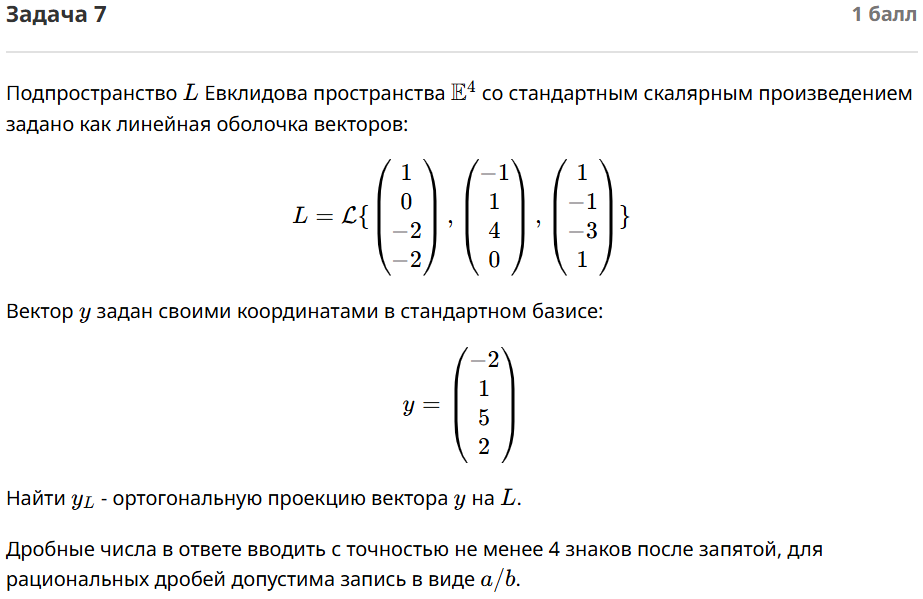

In [62]:
vectors = [
    geolin_vector("1 0 -2 -2"),
    geolin_vector("-1 1 4 0"),
    geolin_vector("1 -1 -3 1")
]
y = geolin_vector("-2 1 5 2")

G = eye(4)
basis = orthonormal_basis(vectors, G)
y_L = projection(basis, y, G)
print(geo(y_L.T))


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

...

<IPython.core.display.Latex object>

Matrix([
[ 1/3,    0, 2*sqrt(2)/3],
[   0,  1/3,           0],
[-2/3,  2/3,   sqrt(2)/6],
[-2/3, -2/3,   sqrt(2)/6]])

<IPython.core.display.Latex object>

<IPython.core.display.Math object>

[-2, 0.7777777778, 5.0555555556, 1.9444444444]


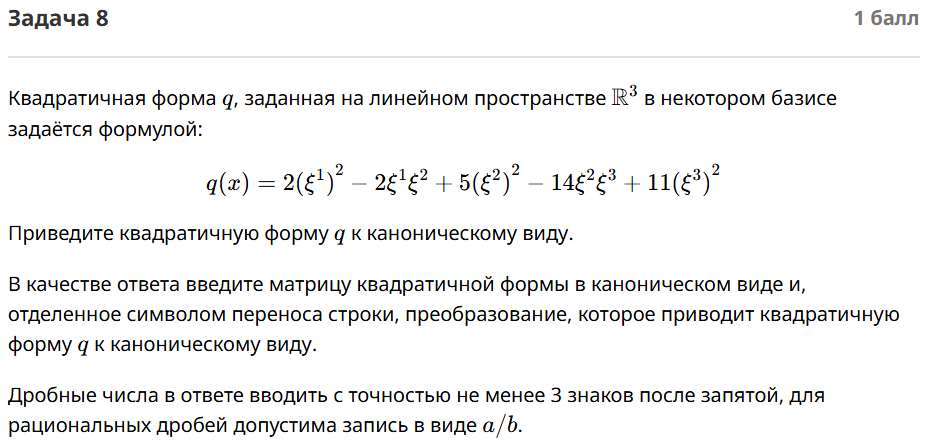

In [63]:
Q = Matrix([
    [2, -1, 0],
    [-1, 5, -7],
    [0, -7, 11]
])

Qd, Td = lagrange_diagonalization(Q)
display(Latex("Ответ"))
print(geo(Qd))
print(geo(Td))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Latex object>

Matrix([
[2,   0,   0],
[0, 9/2,   0],
[0,   0, 1/9]])

...

Matrix([
[1, 0, 0],
[0, 1, 0],
[0, 0, 1]])

<IPython.core.display.Latex object>

Matrix([
[sqrt(2),  -sqrt(2)/2,            0],
[      0, 3*sqrt(2)/2, -7*sqrt(2)/3],
[      0,           0,          1/3]])

<IPython.core.display.Latex object>

[1, 0, 0; 0, 1, 0; 0, 0, 1]
[1.4142135624, -0.7071067812, 0; 0, 2.1213203436, -3.2998316455; 0, 0, 0.3333333333]
